In [6]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import glob

# ================= 配置区域 =================
# 1. 您的 .mat 数据文件夹路径
DATA_DIR = "/home/jovyan/gpu_space/workspace_jiayi/alex_datasets/3D_minimal"

# 2. 您的 Excel 文件名 (请确保文件在当前目录下，或者写绝对路径)
LUT_PATH = "Freesurfer_LUT_alex_labels_jiayi.xlsx" 

# 通道定义
CH_UFA = 14       
CH_AMIDE = 225    
CH_MPRAGE = 341   

def load_colormap(excel_path):
    """直接从 Excel 加载 102 类配色"""
    try:
        # 修改点：使用 read_excel，并指定引擎 (以防万一)
        df = pd.read_excel(excel_path, engine='openpyxl')
        
        # 打印一下列名，确保读取正确 (调试用)
        # print("Excel Columns:", df.columns.tolist())
        
        # 寻找最大 Label ID 以建立颜色矩阵
        # 确保 label 列被当作数字处理，排除非数字干扰
        valid_labels = pd.to_numeric(df['one_hot_loc_alex_label'], errors='coerce').dropna()
        max_label = int(valid_labels.max()) + 10
        
        colors = np.zeros((max_label, 4)) # RGBA Matrix
        colors[0] = [0, 0, 0, 0] # 背景透明
        
        for _, row in df.iterrows():
            try:
                # 读取 Label ID
                lbl_val = row['one_hot_loc_alex_label']
                # 如果是字符串或无法转化的内容，跳过
                if pd.isna(lbl_val) or str(lbl_val).strip() == '[]':
                    continue
                    
                idx = int(lbl_val)
                
                # 读取 RGB 并归一化到 0-1
                r = row['R'] / 255.0
                g = row['G'] / 255.0
                b = row['B'] / 255.0
                
                colors[idx] = [r, g, b, 1.0] # Alpha = 1.0 (不透明)
            except Exception as e:
                # 某些行可能有格式问题，静默跳过即可
                continue
                
        return mcolors.ListedColormap(colors)
        
    except Exception as e:
        print(f"⚠️ 无法读取 Excel 文件 ({e})。")
        print("请检查：1. 文件路径是否正确 2. 是否安装了 openpyxl (pip install openpyxl)")
        return 'tab20'

# --- 主加载逻辑 ---

# 1. 查找数据
mat_files = sorted(list(Path(DATA_DIR).glob('*.mat')))
if not mat_files:
    print(f"⚠️ 警告: 在 {DATA_DIR} 未找到 .mat 文件。请检查路径。")
    # 为了防止报错停止，这里可以放一个伪数据逻辑，但真实运行请确保有文件
else:
    target_file = mat_files[0] 
    print(f"📂 正在加载数据: {target_file.name} ...")

    with h5py.File(target_file, 'r') as f:
        # 数据转置处理
        raw_data = f['data'][:]
        data_vol = np.moveaxis(raw_data, 0, -1)
        
        labels_vol = f['region_labels'][:]
        # 再次确认 Label 维度，如果 Label 也是 [C, X, Y, Z] 格式 (C=1)，也需要转置
        if labels_vol.ndim == 4 and labels_vol.shape[0] == 1:
            labels_vol = labels_vol[0, ...] # 降维成 [X, Y, Z]
        elif labels_vol.ndim == 4:
            labels_vol = np.moveaxis(labels_vol, 0, -1)
            
        print(f"✅ 数据加载完成。Data Shape: {data_vol.shape}")
        
    # 2. 加载 Excel 配色
    custom_cmap = load_colormap(LUT_PATH)
    print("✅ 配色表已就绪。")

📂 正在加载数据: ODP_01_qhlazec_3d_validated_minimal.mat ...
✅ 数据加载完成。Data Shape: (384, 336, 256, 351)
✅ 配色表已就绪。


正在扫描 Sagittal 方向的大脑截面大小...
检测到最大截面位于层 229 (Area: 32162 voxels)
将在以下层生成图像: [222, 225, 228, 231, 234]


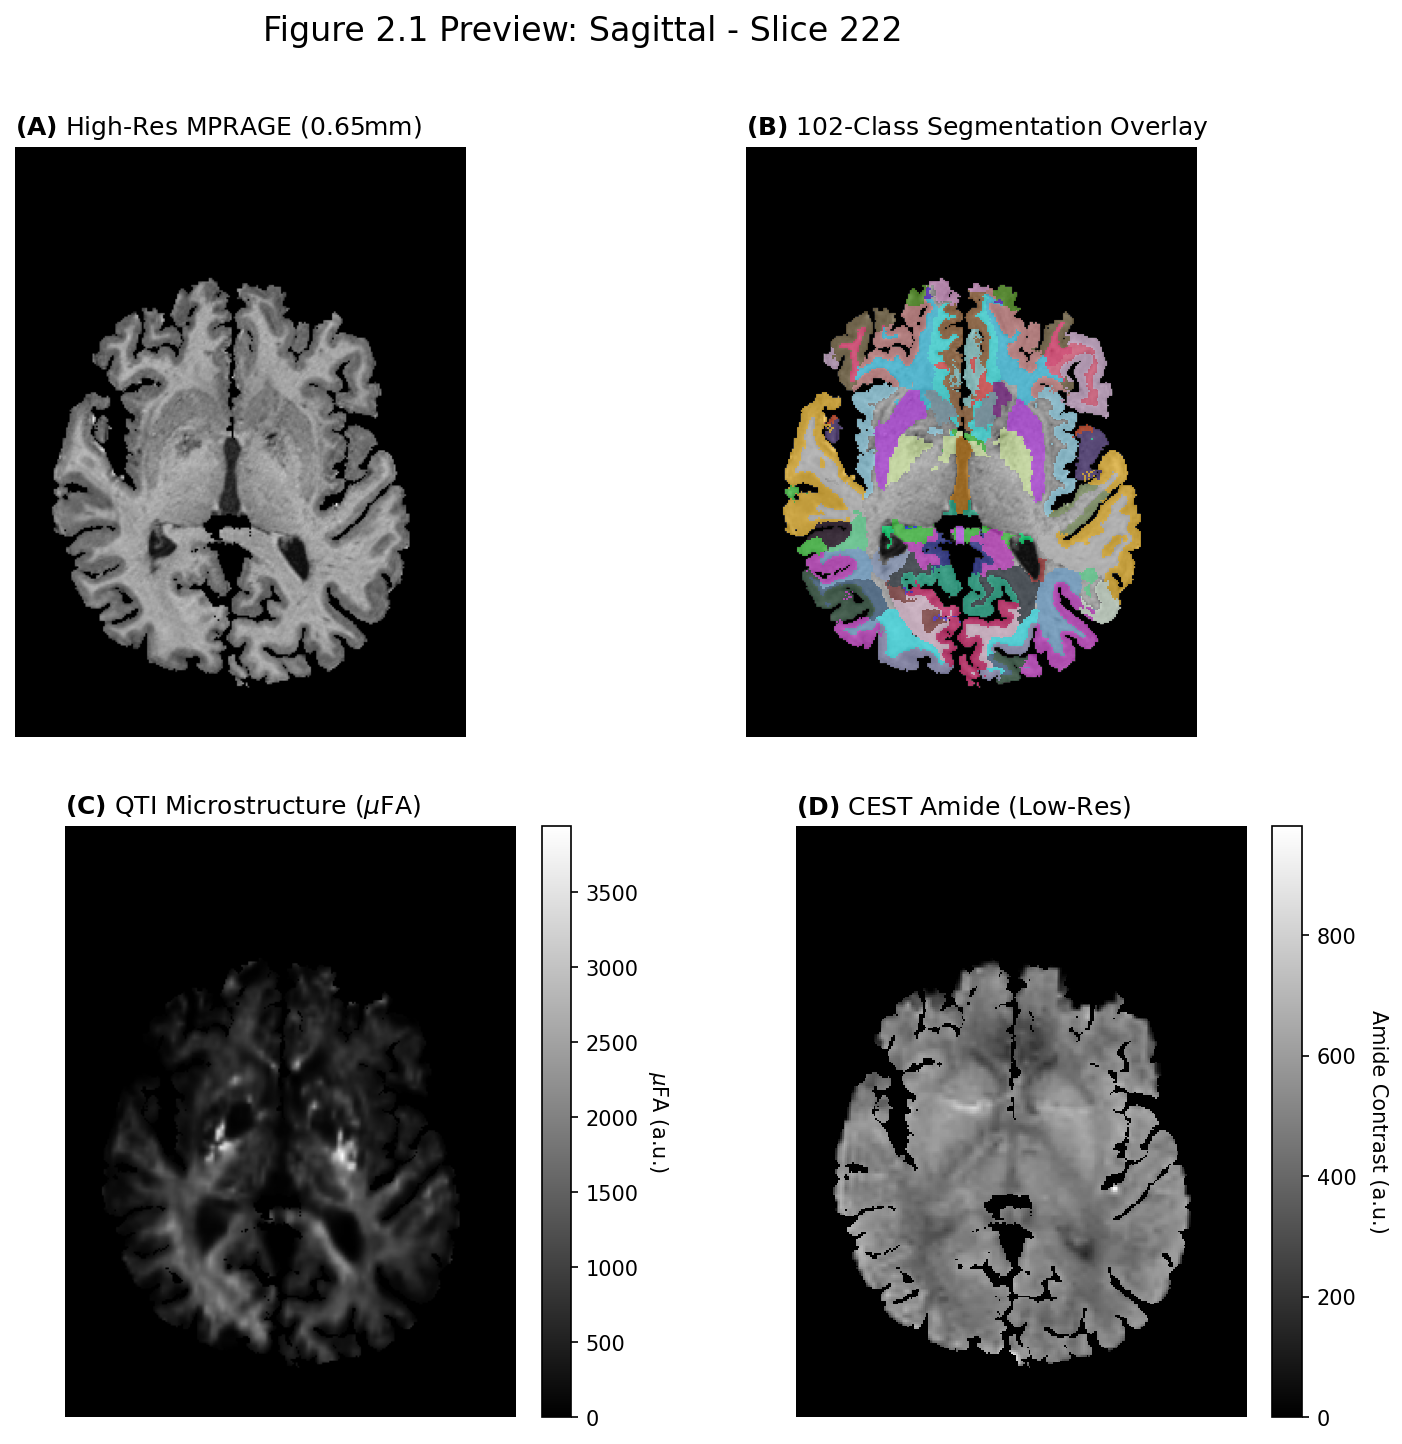

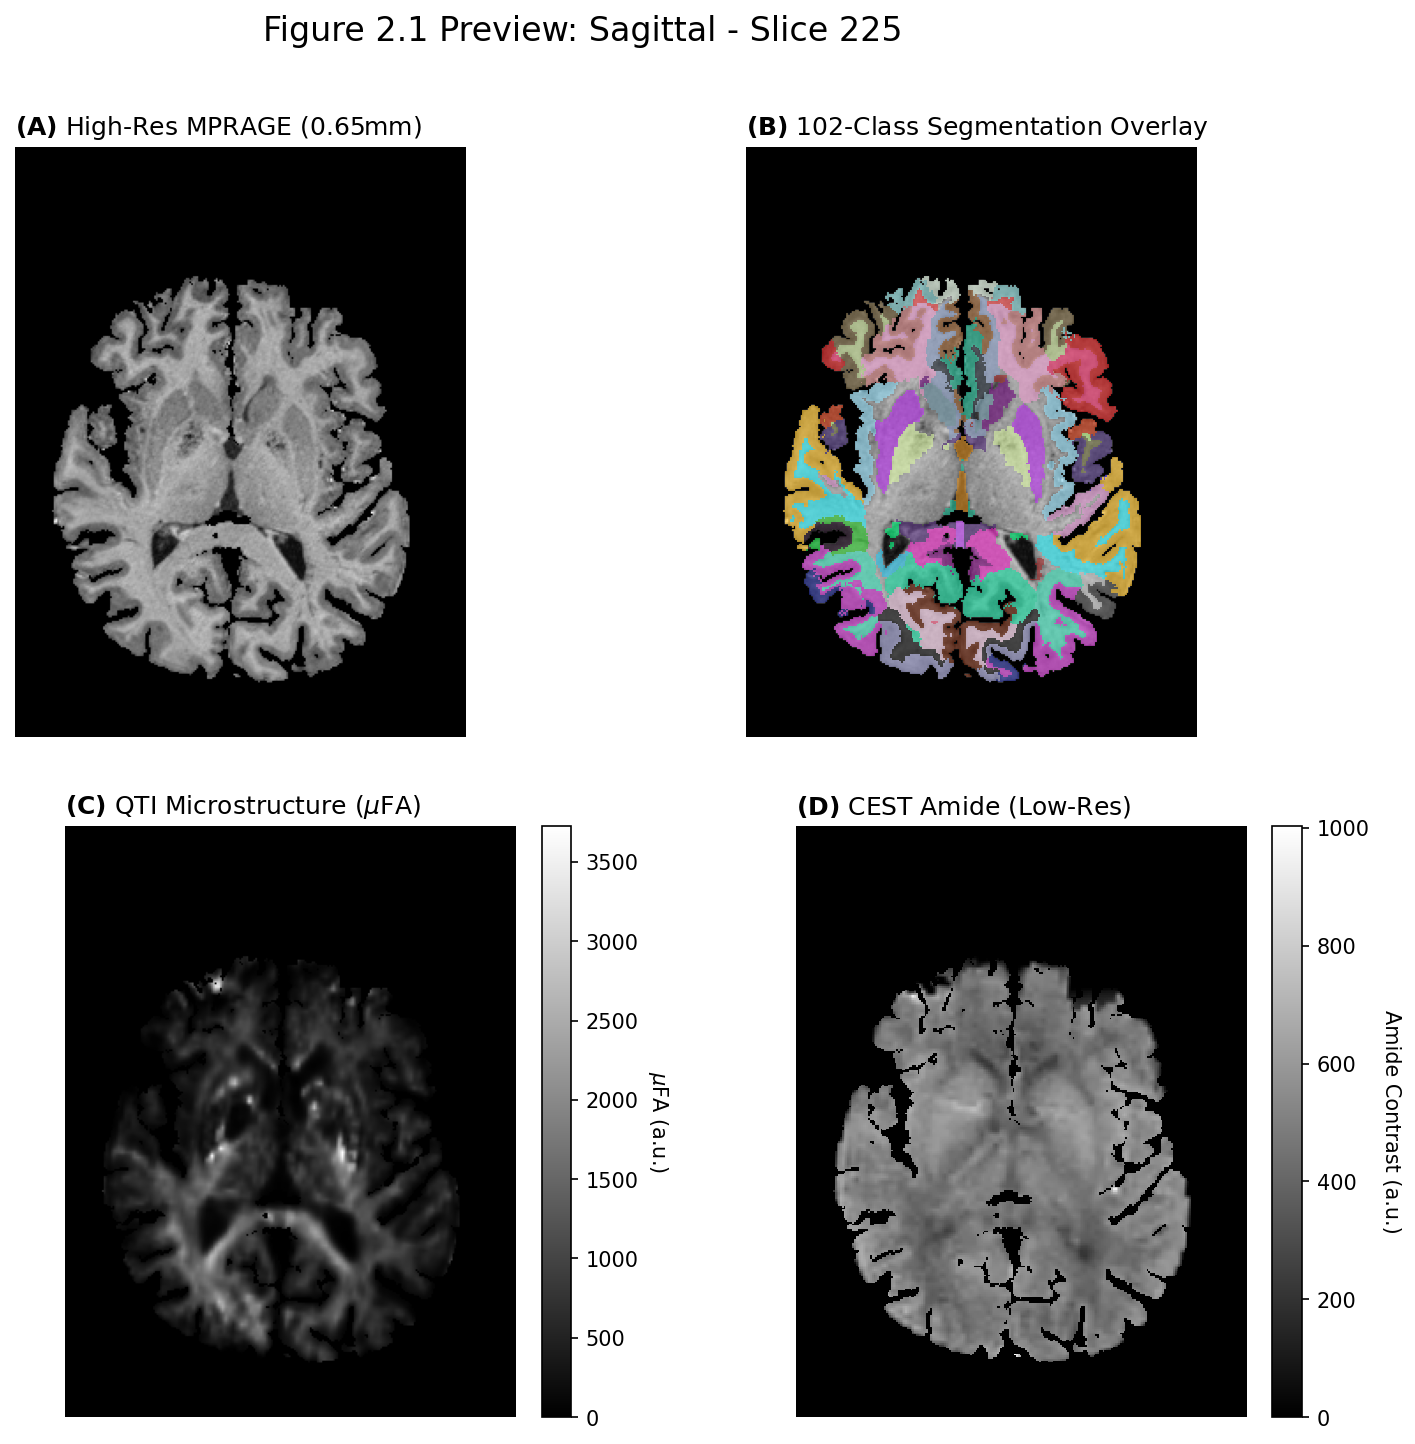

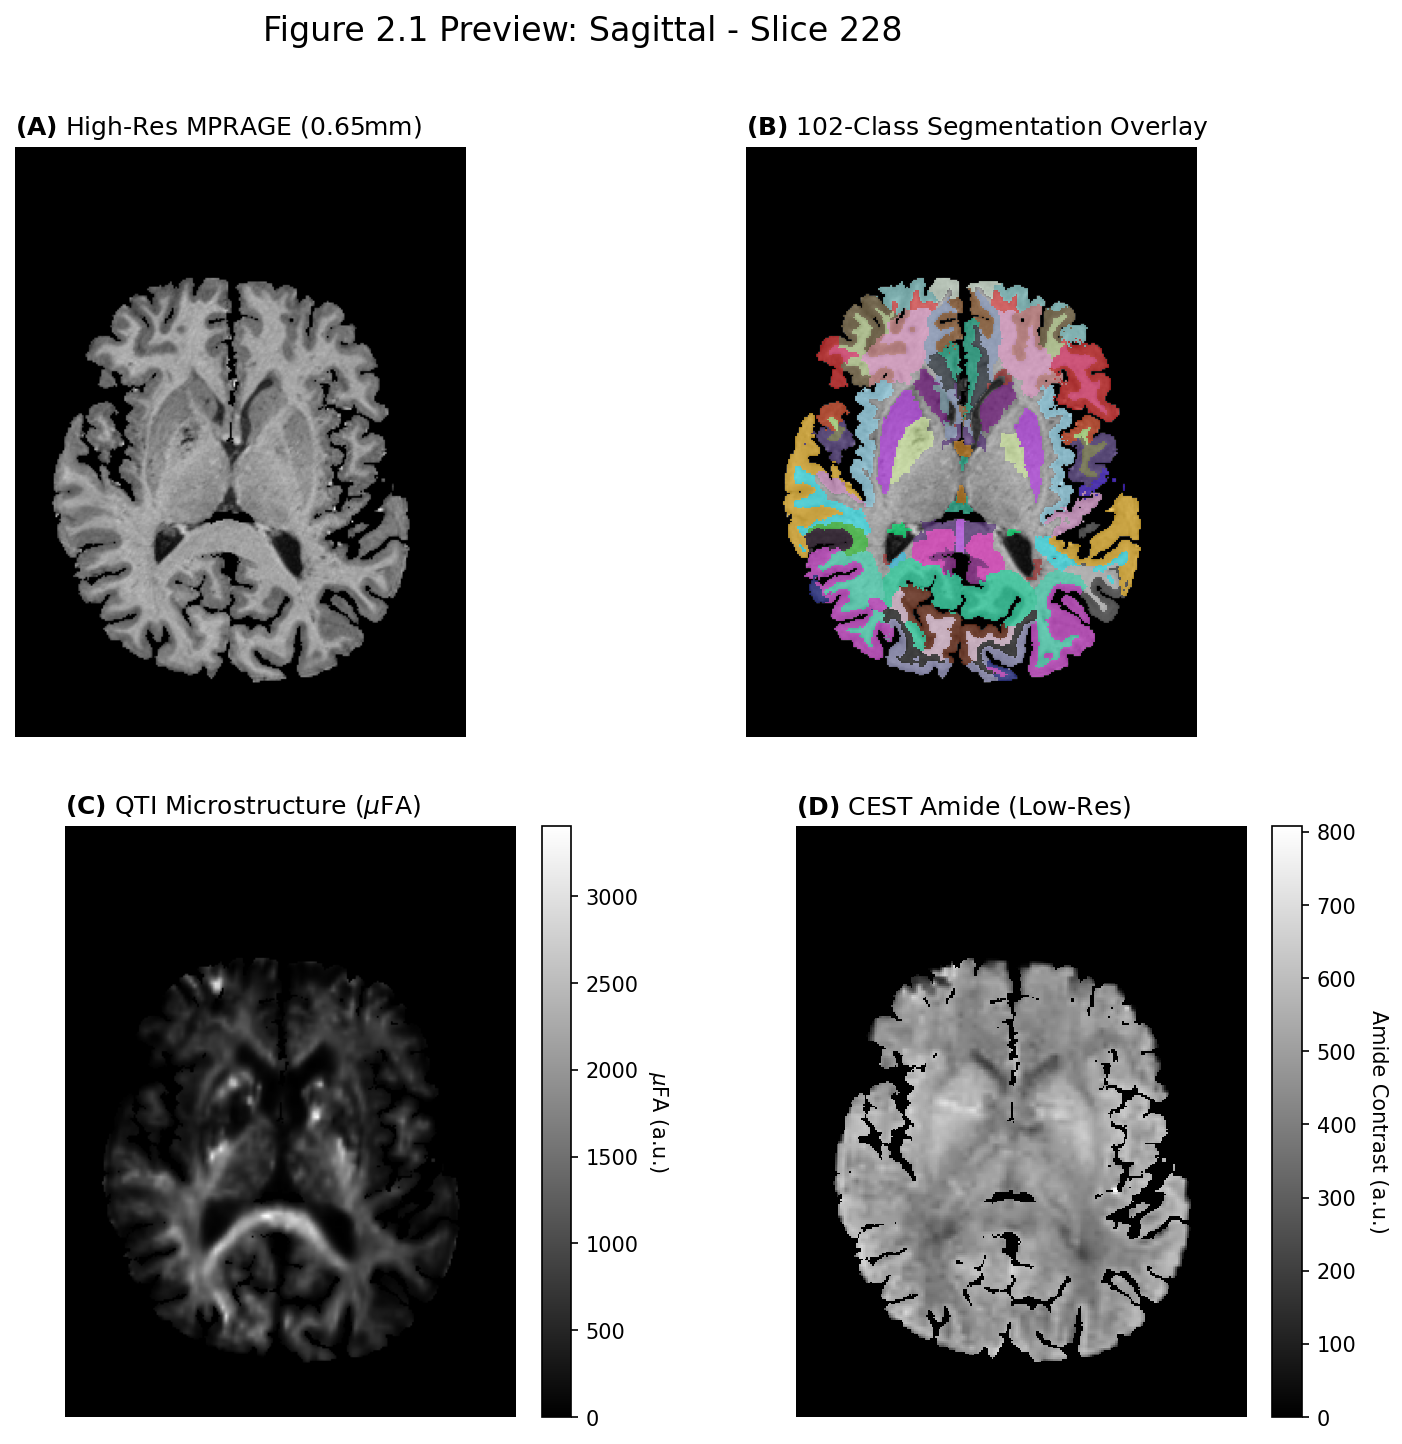

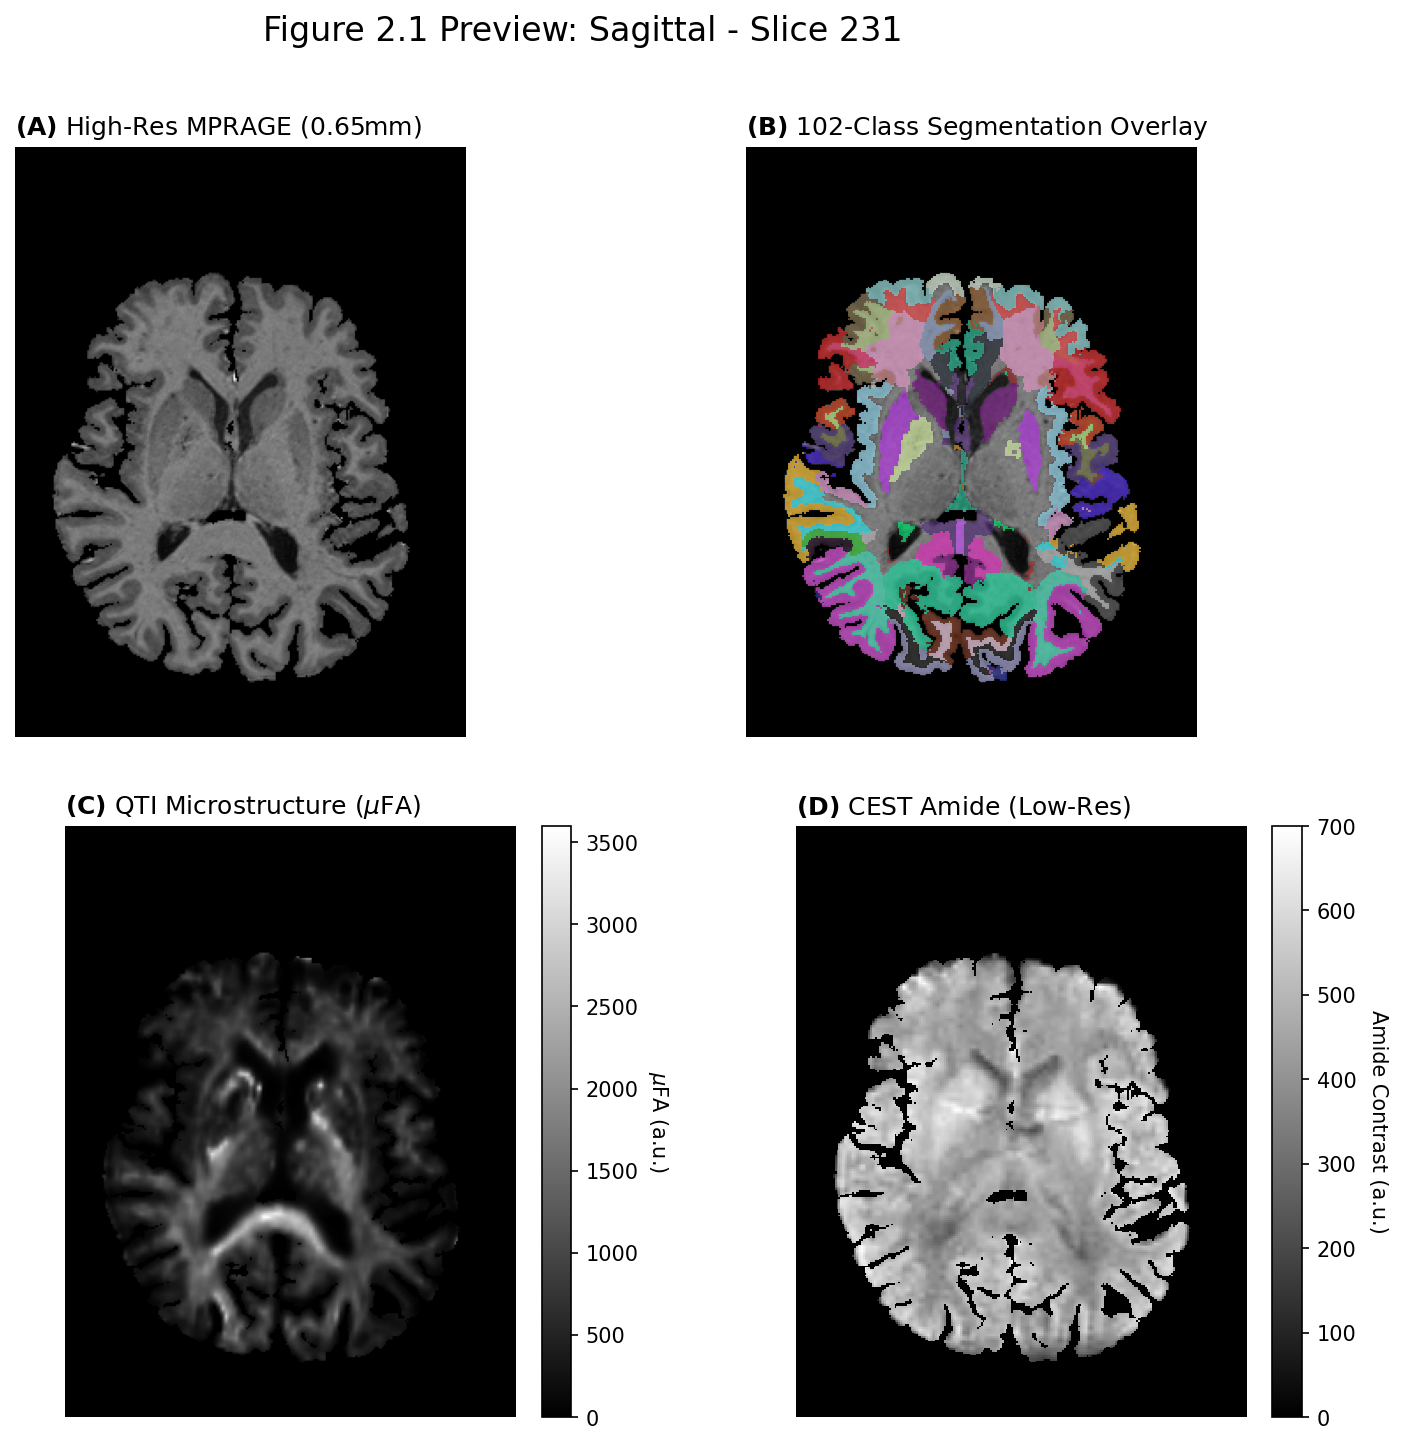

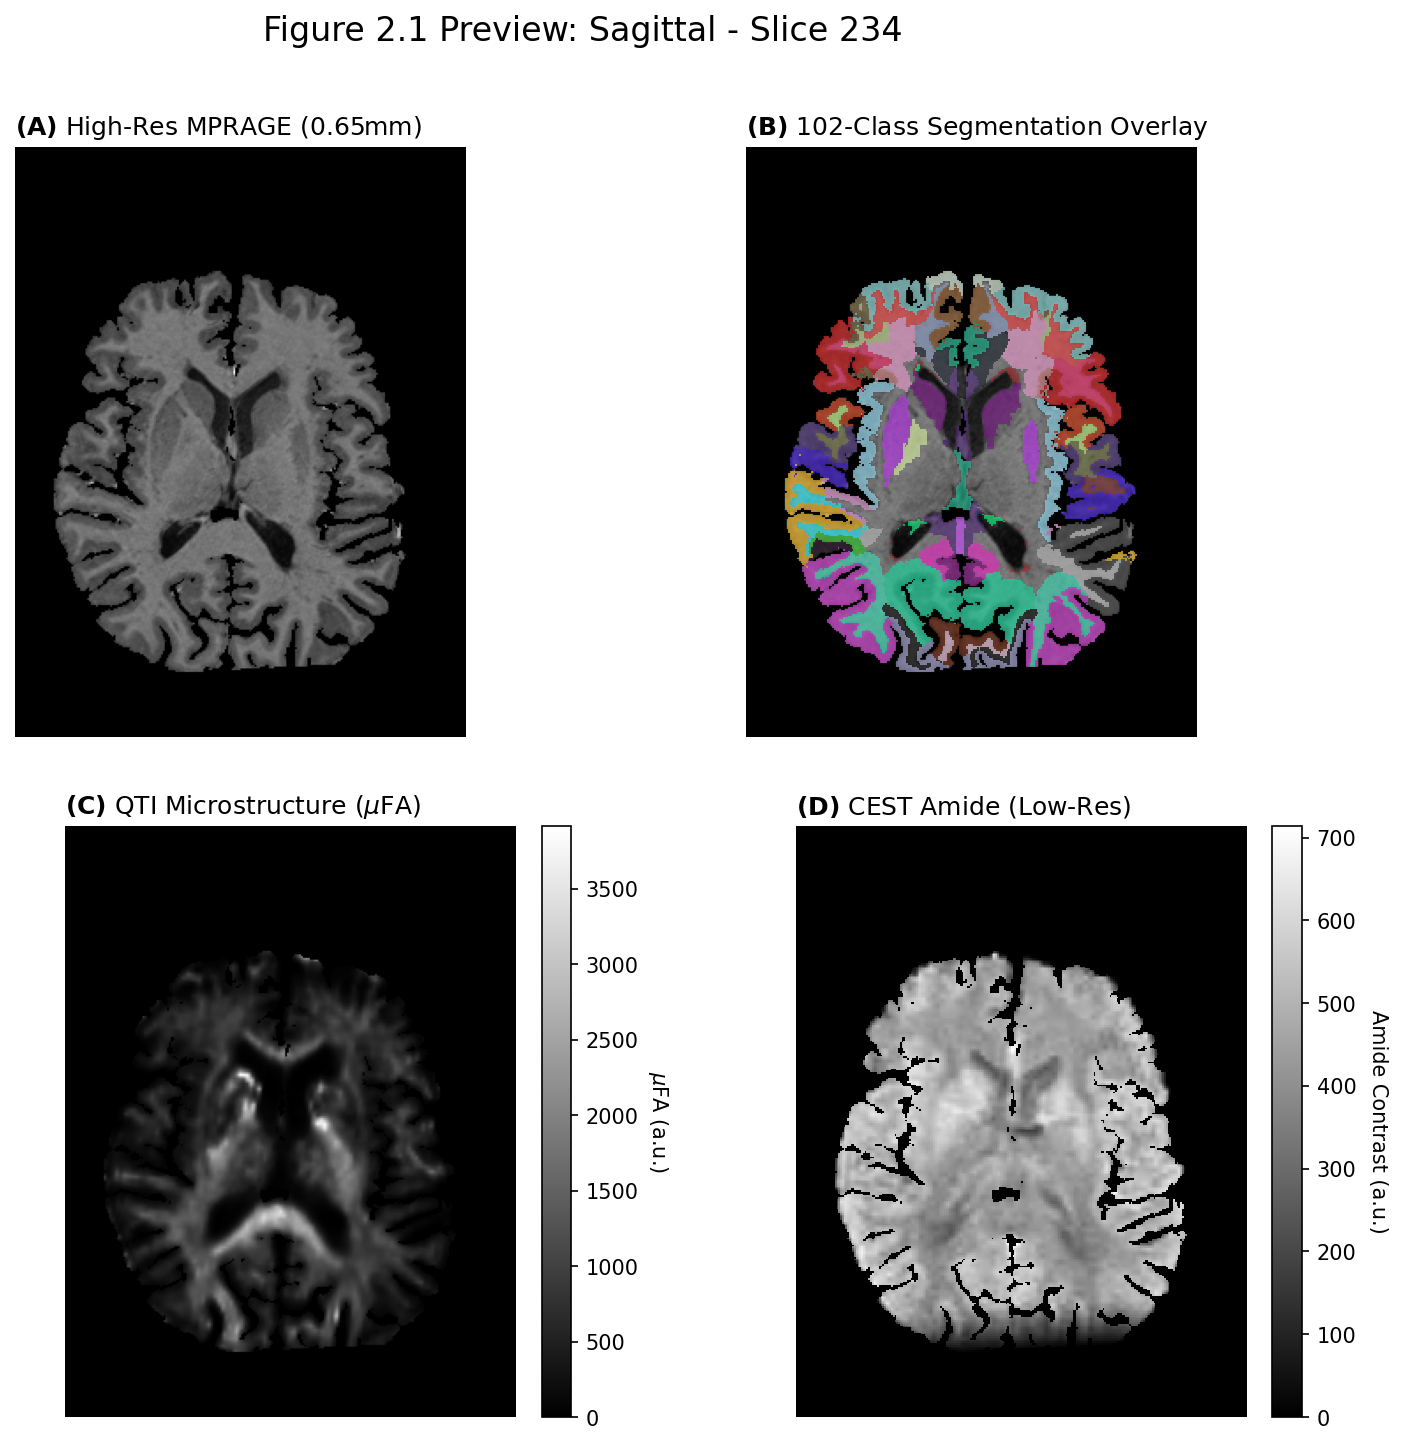

In [11]:
# ================= 绘图参数配置 =================
# 您想看的视角
TARGET_AXIS = 'Sagittal'  # 可选 'Axial', 'Coronal', 'Sagittal'

# 旋转修正参数 (k=1:逆时针90度, k=-1或3:顺时针90度, k=0:不转, k=2:倒立)
# 您之前的反馈是"被左转了90度"，所以之前 k=1 导致了左转。
# 这里我们将 k 改为 0 (相当于右转回正)。如果还不对，请尝试改成 3。
ROTATION_K = 2

# 自动选层参数
NUM_IMAGES = 5     # 您想输出几张图供挑选？
SLICE_STEP = 3     # 每隔几层画一张

def auto_find_best_range(labels_vol, axis, num_imgs, step):
    """
    智能检测：计算每一层的非零像素数量（大脑面积），
    自动定位到大脑最大的位置，并返回一个切片范围。
    """
    print(f"正在扫描 {axis} 方向的大脑截面大小...")
    
    # 计算每个切片的非零像素数 (脑区面积)
    if axis == 'Axial':    # Z轴切片 (Index 2)
        # Sum over X, Y
        area_per_slice = np.count_nonzero(labels_vol, axis=(0, 1))
    elif axis == 'Coronal': # Y轴切片 (Index 1)
        # Sum over X, Z
        area_per_slice = np.count_nonzero(labels_vol, axis=(0, 2))
    else: # Sagittal (X轴切片, Index 0)
        # Sum over Y, Z
        area_per_slice = np.count_nonzero(labels_vol, axis=(1, 2))
    
    # 找到最大截面（大脑中心）
    center_idx = np.argmax(area_per_slice)
    max_area = area_per_slice[center_idx]
    
    # 简单的阈值检查，防止选到空数据
    if max_area < 100:
        print("⚠️ 警告：检测到的脑区面积非常小，数据可能为空或阈值不匹配。")
    
    print(f"检测到最大截面位于层 {center_idx} (Area: {max_area} voxels)")
    
    # 以最大截面为中心，生成范围
    # 例如：中心 180，要画 5 张，步长 3 -> 范围覆盖 180 +/- (5*3)/2
    half_span = (num_imgs * step) // 2
    start = max(0, center_idx - half_span)
    end = min(len(area_per_slice), center_idx + half_span + step) # 多取一点buffer
    
    # 生成具体的切片索引列表
    # 确保索引在 start 和 end 之间
    slice_indices = range(start, end, step)
    # 截取用户需要的张数
    slice_indices = list(slice_indices)[:num_imgs]
    
    return slice_indices

def get_slice_corrected(data, labels, axis, idx, k_rot):
    """提取切片并应用旋转修正"""
    if axis == 'Axial':
        sl_d = data[:, :, idx, :]
        sl_l = labels[:, :, idx]
    elif axis == 'Coronal':
        sl_d = data[:, idx, :, :]
        sl_l = labels[:, idx, :]
    else: # Sagittal
        sl_d = data[idx, :, :, :]
        sl_l = labels[idx, :, :]
        
    # 处理 Label 维度 (如果是 4D)
    if sl_l.ndim == 3: sl_l = sl_l[0, ...] 
    
    # 旋转修正
    sl_d = np.rot90(sl_d, k=k_rot)
    sl_l = np.rot90(sl_l, k=k_rot)
    
    return sl_d, sl_l

# ================= 主执行逻辑 =================

# 1. 智能计算切片范围
target_slices = auto_find_best_range(labels_vol, TARGET_AXIS, NUM_IMAGES, SLICE_STEP)
print(f"将在以下层生成图像: {target_slices}")

# 2. 循环绘图
for slice_idx in target_slices:
    try:
        # 获取切片
        sl_data, sl_label = get_slice_corrected(data_vol, labels_vol, TARGET_AXIS, slice_idx, ROTATION_K)
        
        # 提取通道
        img_mprage = sl_data[..., CH_MPRAGE]
        img_ufa    = sl_data[..., CH_UFA]
        img_amide  = sl_data[..., CH_AMIDE]
        
        # --- 绘图 (2x2) ---
        fig, axes = plt.subplots(2, 2, figsize=(12, 11), dpi=150)
        fig.suptitle(f"Figure 2.1 Preview: {TARGET_AXIS} - Slice {slice_idx}", fontsize=16, y=0.96)
        plt.subplots_adjust(wspace=0.1, hspace=0.15)

        # Panel A: MPRAGE (Grayscale)
        ax = axes[0, 0]
        ax.imshow(img_mprage, cmap='gray', aspect='equal')
        ax.set_title(r"$\bf{(A)}$ High-Res MPRAGE (0.65mm)", loc='left', fontsize=12)
        ax.axis('off')

        # Panel B: Segmentation (Overlay)
        ax = axes[0, 1]
        ax.imshow(img_mprage, cmap='gray', aspect='equal')
        masked_lbl = np.ma.masked_where(sl_label == 0, sl_label)
        ax.imshow(masked_lbl, cmap=custom_cmap, alpha=0.6, interpolation='nearest')
        ax.set_title(r"$\bf{(B)}$ 102-Class Segmentation Overlay", loc='left', fontsize=12)
        ax.axis('off')

        # Panel C: QTI uFA (Grayscale + Colorbar)
        ax = axes[1, 0]
        im_c = ax.imshow(img_ufa, cmap='gray', aspect='equal') 
        ax.set_title(r"$\bf{(C)}$ QTI Microstructure ($\mu$FA)", loc='left', fontsize=12)
        ax.axis('off')
        cbar = plt.colorbar(im_c, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("$\mu$FA (a.u.)", rotation=270, labelpad=15)

        # Panel D: CEST Amide (Grayscale + Colorbar + Low Res)
        ax = axes[1, 1]
        im_d = ax.imshow(img_amide, cmap='gray', aspect='equal', interpolation='nearest')
        ax.set_title(r"$\bf{(D)}$ CEST Amide (Low-Res)", loc='left', fontsize=12)
        ax.axis('off')
        cbar = plt.colorbar(im_d, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Amide Contrast (a.u.)", rotation=270, labelpad=15)

        plt.show() 
        
    except IndexError as e:
        print(f"层 {slice_idx} 读取出错: {e}")
        continue

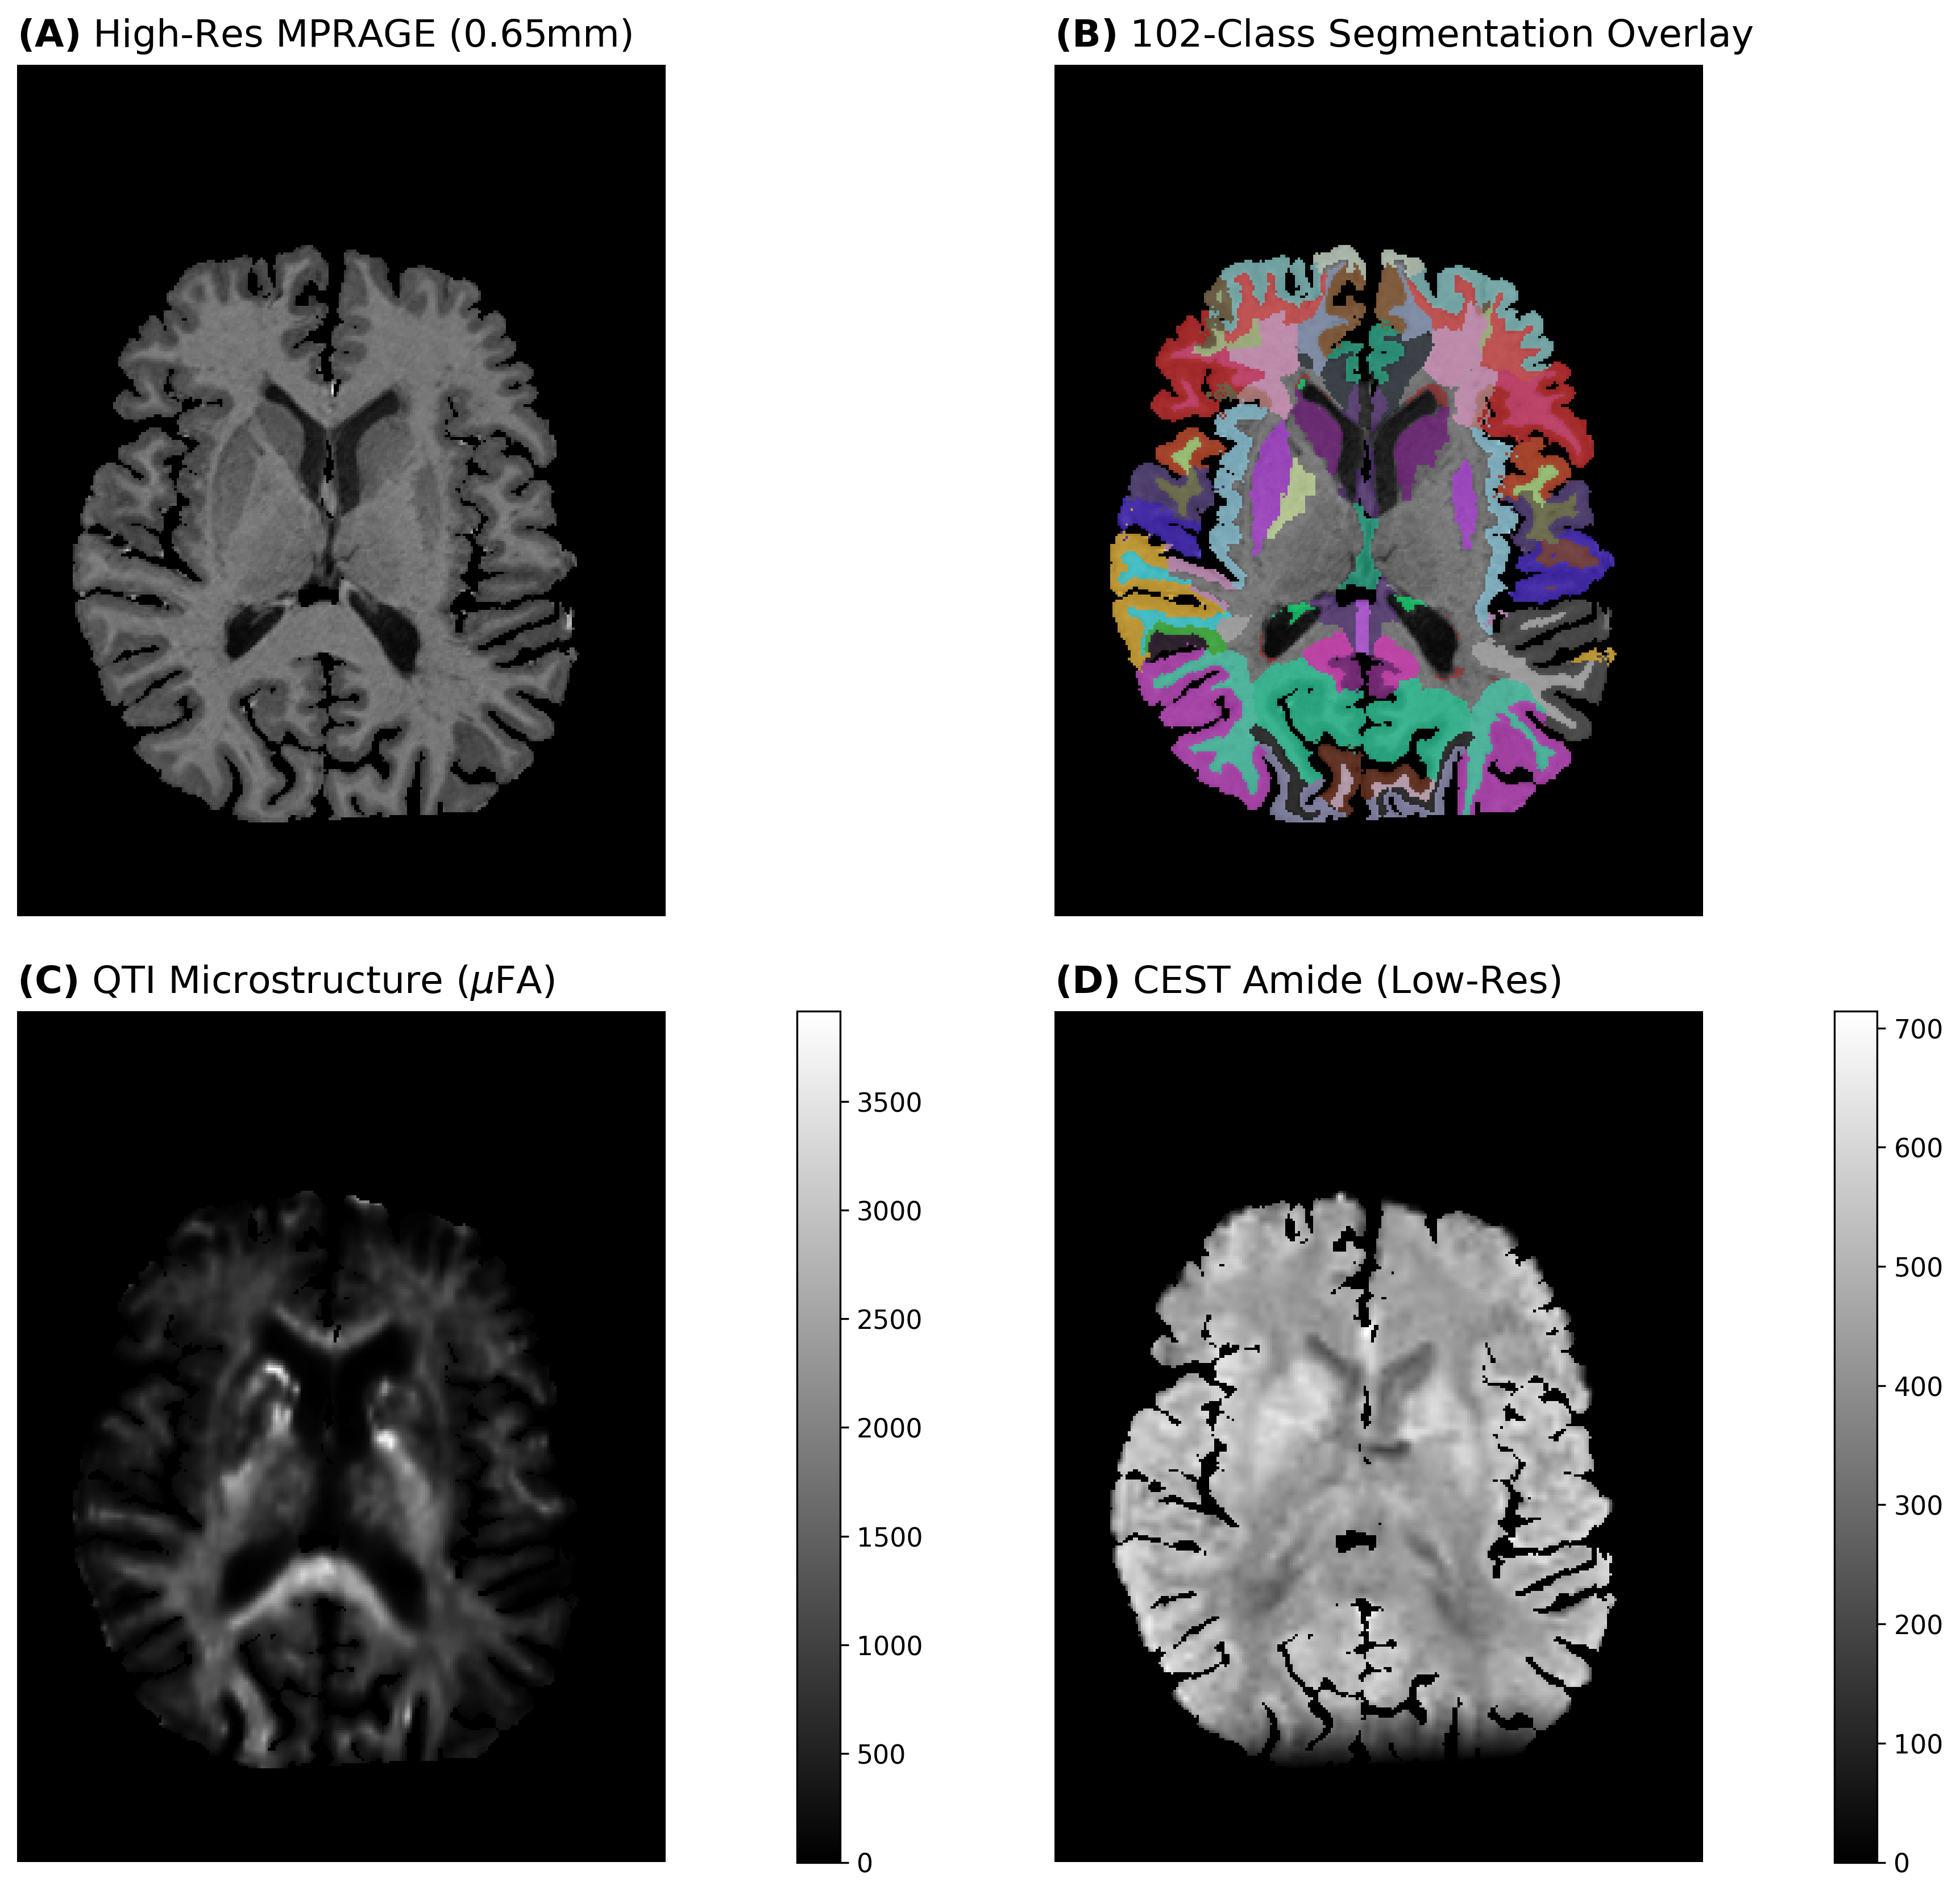

In [14]:
# --- 绘图：GridSpec 预留 colorbar 栏位，严格对齐 ---
fig = plt.figure(figsize=(12, 11), dpi=300, constrained_layout=True)

# 不要大标题：不要 fig.suptitle(...)

# 版式参数（论文友好）
TITLE_FS = 16   # 小标题字号（可再加到 18）
CBAR_FS  = 13   # colorbar label 字号
TICK_FS  = 11   # colorbar tick 字号（灰度条刻度）

gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1.0, 0.05, 1.0, 0.05],
    wspace=0.05,
    hspace=0.05
)

# --- Row 1 ---
axA  = fig.add_subplot(gs[0, 0]); caxA = fig.add_subplot(gs[0, 1])
axB  = fig.add_subplot(gs[0, 2]); caxB = fig.add_subplot(gs[0, 3])

# --- Row 2 ---
axC  = fig.add_subplot(gs[1, 0]); caxC = fig.add_subplot(gs[1, 1])
axD  = fig.add_subplot(gs[1, 2]); caxD = fig.add_subplot(gs[1, 3])

# Panel A: MPRAGE
axA.imshow(img_mprage, cmap='gray', aspect='equal')
axA.set_title(r"$\bf{(A)}$ High-Res MPRAGE (0.65mm)", loc='left', fontsize=TITLE_FS, pad=8)
axA.axis('off')
caxA.axis('off')  # 保留对齐栏位

# Panel B: Segmentation Overlay
axB.imshow(img_mprage, cmap='gray', aspect='equal')
masked_lbl = np.ma.masked_where(sl_label == 0, sl_label)
axB.imshow(masked_lbl, cmap=custom_cmap, alpha=0.6, interpolation='nearest')
axB.set_title(r"$\bf{(B)}$ 102-Class Segmentation Overlay", loc='left', fontsize=TITLE_FS, pad=8)
axB.axis('off')
caxB.axis('off')

# Panel C: QTI uFA + Colorbar
imC = axC.imshow(img_ufa, cmap='gray', aspect='equal')
axC.set_title(r"$\bf{(C)}$ QTI Microstructure ($\mu$FA)", loc='left', fontsize=TITLE_FS, pad=8)
axC.axis('off')
cbC = fig.colorbar(imC, cax=caxC)
# cbC.set_label("$\mu$FA (a.u.)", rotation=270, labelpad=18, fontsize=CBAR_FS)
cbC.ax.tick_params(labelsize=TICK_FS)

# Panel D: CEST Amide + Colorbar
imD = axD.imshow(img_amide, cmap='gray', aspect='equal', interpolation='nearest')
axD.set_title(r"$\bf{(D)}$ CEST Amide (Low-Res)", loc='left', fontsize=TITLE_FS, pad=8)
axD.axis('off')
cbD = fig.colorbar(imD, cax=caxD)
# cbD.set_label("Amide Contrast (a.u.)", rotation=270, labelpad=18, fontsize=CBAR_FS)
cbD.ax.tick_params(labelsize=TICK_FS)

plt.show()
